---
<a id="top"></a>
# Tutorial: FALP and Self-Guided ALP for Inventory Control
---
This notebook is a compact, end-to-end tutorial on approximate linear programming for a single-product inventory Markov decision process. It is written to be approachable for readers who want both the computational workflow and the modeling logic.

**Learning goals**
- understand what is being approximated in FALP and in self-guided ALP
- see how the random-feature basis enters the value-function approximation
- compare lower bounds, upper bounds, and optimality gaps as model size grows
- visualize how guiding constraints change the fitted value functions and state-relevance weights


### Table of Contents

1. [Setup](#setup)
2. [Imports and Shared Style](#imports)
3. [Problem Map and Notation](#notation)
4. [FALP Experiments](#falp)
5. [FALP Plots](#falp-plots)
6. [Self-Guided ALP Experiments](#sgalp)
7. [Self-Guided ALP Plots](#sgalp-plots)
8. [FALP vs SGALP Bound Comparison](#bound-comparison)
9. [Understanding the Guiding Mechanism](#guiding)



---
<a id="setup"></a>
## 1. Setup

Run the next cell once if you want the notebook to create a lightweight local environment. If you already have the dependencies installed, you can skip it.


In [1]:
%%bash

if python3 - <<'PY_DEPENDENCIES'
import importlib.util
required = ["numpy", "scipy", "matplotlib", "emcee"]
missing = [name for name in required if importlib.util.find_spec(name) is None]
raise SystemExit(1 if missing else 0)
PY_DEPENDENCIES
then
    echo "Core tutorial dependencies already available; skipping environment setup."
    exit 0
fi

echo "Building a Python environment ..."
python3 -m venv ../.venv >/dev/null 2>&1
source ../.venv/bin/activate
python -m pip install --upgrade pip >/dev/null 2>&1
python -m pip install numpy scipy matplotlib emcee jupyter ipykernel >/dev/null 2>&1
echo "All done."


Building a Python environment ...
All done.


<a id="imports"></a>
## 2. Imports and Shared Style

The notebooks now live in `notebooks/`, so the next cell first adds the parent project folder to Python's import path. After that, we import the shared modules from the main folder and the ALP-specific classes/configs from `self_guided_alp/`.


In [2]:
import sys
from pathlib import Path


def find_project_root(start_path: Path) -> Path:
    """
    Find the tutorial project root by looking for the shared Python modules.

    Args:
        start_path: Directory from which to begin the upward search.
    """
    for candidate in (start_path, *start_path.parents):
        if (candidate / "helper.py").exists() and (candidate / "config.py").exists():
            return candidate
    raise RuntimeError("Could not locate the tutorial project root.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
REPOSITORY_ROOT = PROJECT_ROOT.parent
for import_root in [PROJECT_ROOT, REPOSITORY_ROOT]:
    if str(import_root) not in sys.path:
        sys.path.insert(0, str(import_root))


from config import CONTINUOUS_MDP_NOTEBOOK_CONFIG, make_shared_evaluation_configs
from helper import (
    apply_tutorial_plot_style,
    run_falp_grid,
    run_sgalp_grid,
    run_falp_and_sgalp_comparison,
    plot_value_function_curves,
    plot_bound_boxplots,
    plot_falp_vs_sgalp_bound_boxplots,
    plot_falp_vs_sgalp_vfas_and_relevance,
    plot_falp_vs_sgalp_policy_costs,
    summarize_falp_vs_sgalp_policy_costs,
)
from self_guided_alp.sgalp import SelfGuidedALP

apply_tutorial_plot_style()

tutorial_config = CONTINUOUS_MDP_NOTEBOOK_CONFIG
shared_lower_bound_config, shared_policy_config = make_shared_evaluation_configs()


<a id="notation"></a>
## 3. Problem Map and Notation

| Object | Meaning | Where it appears |
| --- | --- | --- |
| `s` | current inventory state | horizontal axis in the value-function plots |
| `a` | order quantity | chosen by the policy |
| `\hat V(s)` | approximate value function | fitted by FALP or SGALP |
| `m` | number of random Fourier features | controls approximation richness |
| lower bound | sampling-based performance certificate | should go up as the approximation improves |
| upper bound | simulated greedy-policy cost | should go down as the policy improves |
| optimality gap | relative distance between upper and lower bounds | smaller is better |

The inventory instance is the same throughout the notebook. What changes is the approximation architecture and the way constraints are enforced.


---
<a id="falp"></a>
## 4. FALP Experiments

We first solve the fitted approximate linear program (FALP) for a sequence of feature counts. The code below separates the experiment into three parameter bundles:
- `falp_config` controls the basis family and LP sampling sizes
- `falp_lower_bound_config` controls the stochastic lower-bound estimator
- `falp_policy_config` controls greedy-policy simulation for the upper bound

This makes the design choices explicit and avoids long constructor calls.


In [3]:
# This is the expensive FALP cell. Run it once and reuse the cached results below.
falp_feature_counts = list(tutorial_config.falp_feature_counts)
falp_seed_grid = list(tutorial_config.seeds)
falp_config = tutorial_config.falp

falp_results = run_falp_grid(
    feature_counts=falp_feature_counts,
    seeds=falp_seed_grid,
    falp_config=falp_config,
    lower_bound_config=shared_lower_bound_config,
    policy_config=shared_policy_config,
    inventory_config=tutorial_config.inventory,
    compute_upper_bound=True,
)


    seed   # features         FALP obj           CVL lb      policy cost          best lb          best ub    opt gap %   time (sec)
------------------------------------------------------------------------------------------------------------------------------------------
     111            0             86.2             84.2          15810.4             84.2          15810.4         99.5         8.79
     111            1           2193.0           2173.4           7976.7           2173.4           7976.7         72.8        12.86
     111            2           2250.0           2203.5           5438.8           2203.5           5438.8         59.5        14.23
     111            3           2766.7           1722.7           3979.9           2203.5           3979.9         44.6        16.16
     111            4           4331.0           2996.8           3823.5           2996.8           3823.5         21.6        17.35
     111            5           4581.6           3241.6        

---
<a id="falp-plots"></a>
## 5. FALP Plots

The first figure shows two complementary views:
- left: the fitted value functions on a log scale, which makes shape differences easier to see
- right: the mean FALP objective value as the basis gets richer

For the curves we use one representative seed so that the geometry of the fitted functions is easy to inspect.


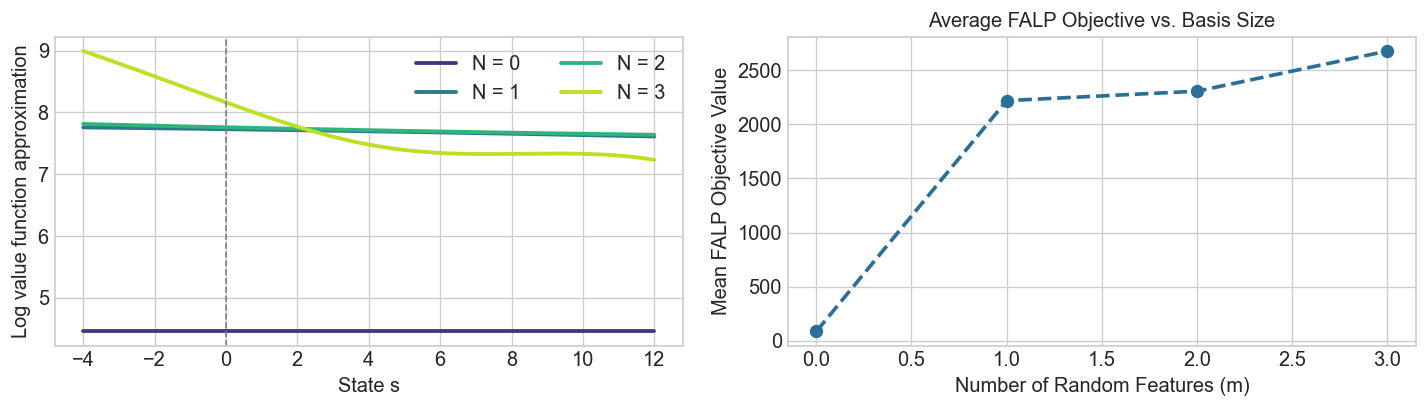

In [4]:
VALUE_CURVE_FEATURE_COUNTS = list(falp_feature_counts[:4])
VALUE_CURVE_GRID_SIZE = 300
VALUE_CURVE_COLORMAP = "viridis"
VALUE_CURVE_PLOT_SEED = falp_seed_grid[0]

plot_value_function_curves(
    falp_results,
    VALUE_CURVE_FEATURE_COUNTS,
    falp_seed_grid,
    algorithm_name="FALP",
    grid_size=VALUE_CURVE_GRID_SIZE,
    colormap=VALUE_CURVE_COLORMAP,
    objective_color="#2a6f97",
    plot_seed=VALUE_CURVE_PLOT_SEED,
)


The next figure summarizes performance across random seeds. When you read it, the ideal pattern is:
- lower bounds rise,
- upper bounds fall,
- the gap between them shrinks.


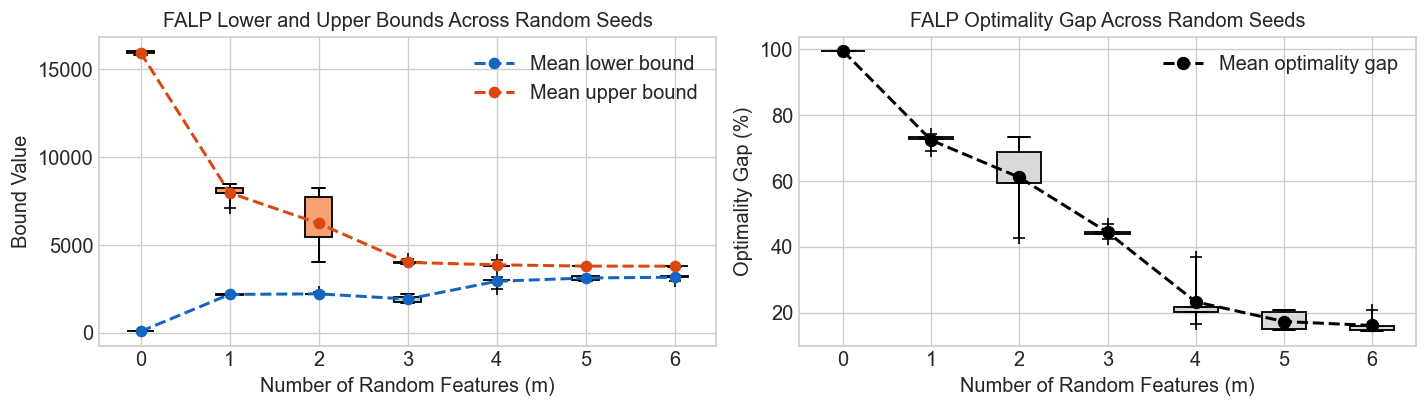

In [5]:
plot_bound_boxplots(
    falp_results,
    falp_feature_counts,
    falp_seed_grid,
    algorithm_name="FALP",
)


---
<a id="sgalp"></a>
## 6. Self-Guided ALP Experiments

Self-guided ALP reuses the same basic ingredients, but it solves a sequence of models and adds guiding constraints so the new approximation does not drift too far below the previous one on sampled states.

In the config below, the `guiding` block isolates the parameters that are specific to SGALP. That makes it easier to explain what is algorithm-specific versus what is shared with plain FALP.


In [6]:
# This is the expensive SGALP cell. Run it once and reuse the cached results below.
sgalp_feature_counts = list(tutorial_config.sgalp_feature_counts)
sgalp_seed_grid = list(tutorial_config.seeds)
sgalp_config = tutorial_config.sgalp

sgalp_results = run_sgalp_grid(
    feature_counts=sgalp_feature_counts,
    sgalp_class=SelfGuidedALP,
    seeds=sgalp_seed_grid,
    sgalp_config=sgalp_config,
    lower_bound_config=shared_lower_bound_config,
    policy_config=shared_policy_config,
    inventory_config=tutorial_config.inventory,
    compute_upper_bound=True,
)


    seed   # features        SGALP obj           CVL lb      policy cost          best lb          best ub    opt gap %   time (sec)
------------------------------------------------------------------------------------------------------------------------------------------
     111            0             86.2             84.2          15810.4             84.2          15810.4         99.5         8.71
     111            1           2193.0           2173.4           7976.7           2173.4           7976.7         72.8        12.80
     111            2           2250.0           2203.5           5438.8           2203.5           5438.8         59.5        14.87
     111            3           2694.1           2269.4           4065.3           2269.4           4065.3         44.2        17.19
     111            4           4331.0           2996.8           3823.5           2996.8           3823.5         21.6        18.53
     111            5           4581.6           3241.6        

<a id="sgalp-plots"></a>
## 7. Self-Guided ALP Plots

We now compare the value-function approximations from FALP and SGALP side by side. Both panels use the same feature counts, representative seed, grid, and color map, so each curve color corresponds to the same number of random basis functions in both methods.

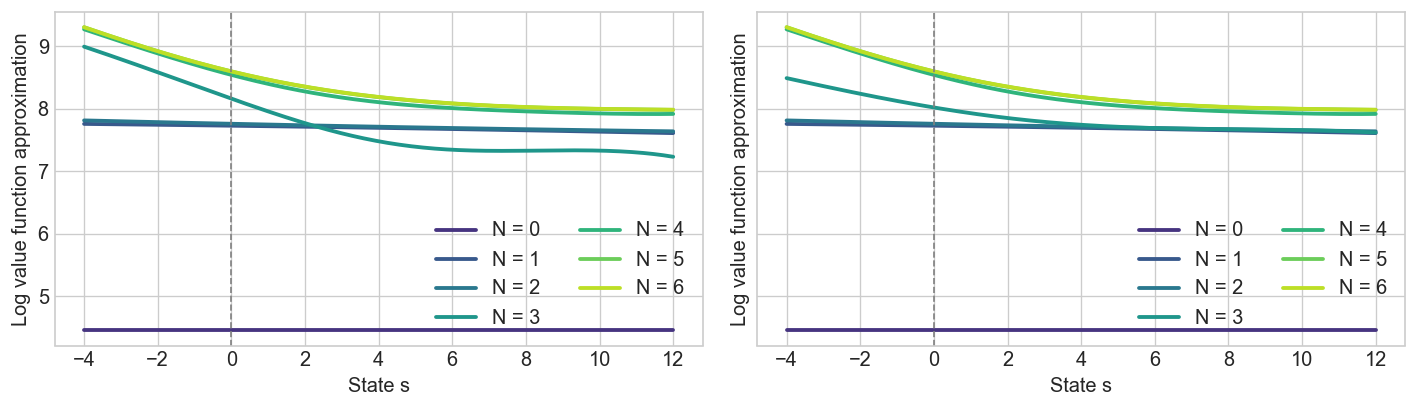

In [7]:
VALUE_CURVE_FEATURE_COUNTS = list(falp_feature_counts)
VALUE_CURVE_GRID_SIZE = 300
VALUE_CURVE_COLORMAP = "viridis"
VALUE_CURVE_PLOT_SEED = falp_seed_grid[0]

plot_value_function_curves(
    falp_results,
    VALUE_CURVE_FEATURE_COUNTS,
    falp_seed_grid,
    algorithm_name="FALP",
    comparison_results_dict=sgalp_results,
    comparison_feature_counts=VALUE_CURVE_FEATURE_COUNTS,
    comparison_seeds=sgalp_seed_grid,
    comparison_algorithm_name="SGALP",
    grid_size=VALUE_CURVE_GRID_SIZE,
    colormap=VALUE_CURVE_COLORMAP,
    comparison_colormap=VALUE_CURVE_COLORMAP,
    plot_seed=VALUE_CURVE_PLOT_SEED,
    comparison_plot_seed=VALUE_CURVE_PLOT_SEED,
    figsize=(12, 3.5),
    fontsize=12,
)


The next figure asks the same question as before: does increasing model richness tighten the interval between the lower and upper bounds? This is the simplest empirical way to compare FALP and SGALP in the tutorial setting.


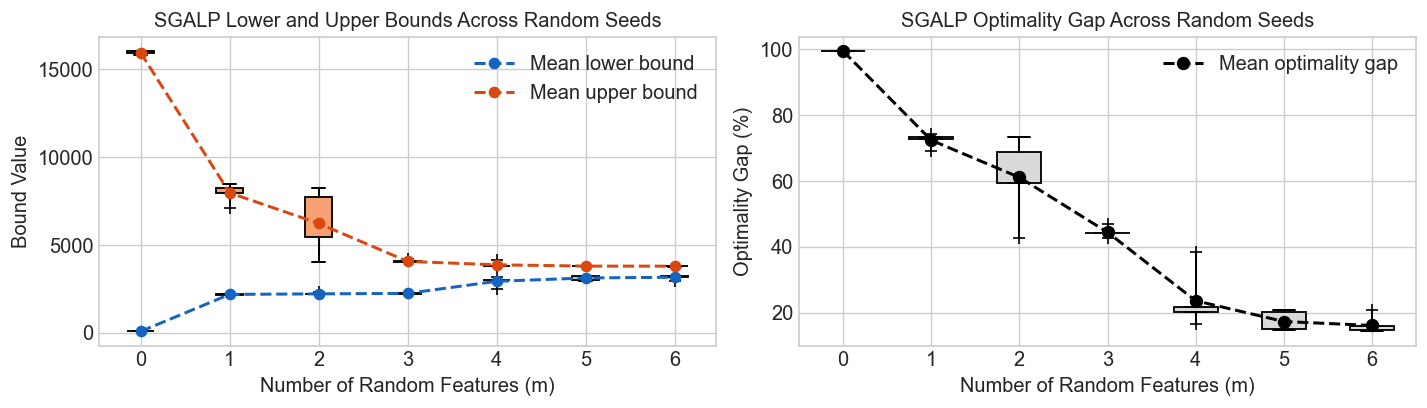

In [8]:
plot_bound_boxplots(
    sgalp_results,
    sgalp_feature_counts,
    sgalp_seed_grid,
    algorithm_name="SGALP",
)


---
<a id="bound-comparison"></a>
## 8. FALP vs SGALP Bound Comparison

The previous sections plotted FALP and SGALP separately. The next figure puts them side by side using the same feature counts, random seeds, lower-bound estimator, and policy-evaluation settings.

Each subplot shows lower-bound and upper-bound boxplots at each feature/stage index `m`. A tighter gap between the two boxes means the fitted approximation gives a stronger certificate for the greedy policy cost. For SGALP, `m` should be read as the final feature count reached by the guided sequence.

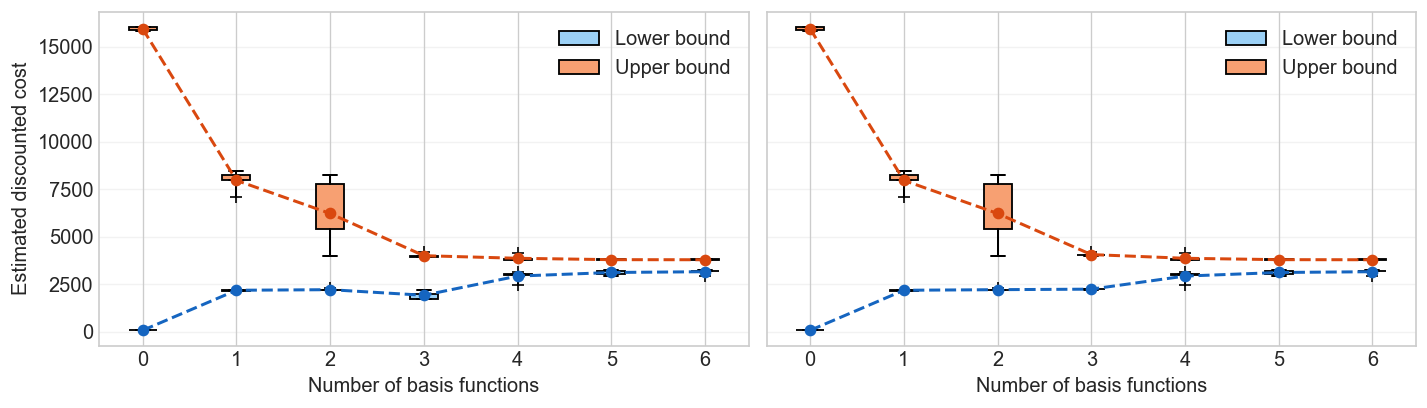

In [9]:
plot_falp_vs_sgalp_bound_boxplots(
    falp_results,
    sgalp_results,
    falp_feature_counts,
    falp_seed_grid,
    figsize=(12, 3.5),
    fontsize=12,
)

---
<a id="guiding"></a>
## 9. Understanding the Guiding Mechanism

This figure is the most diagnostic one in the notebook.

It compares FALP and SGALP stage by stage and also visualizes the updated state-relevance density induced by the guiding constraints. This is useful because the self-guiding mechanism is not only changing the final objective value; it is also changing which regions of the state space receive extra attention.


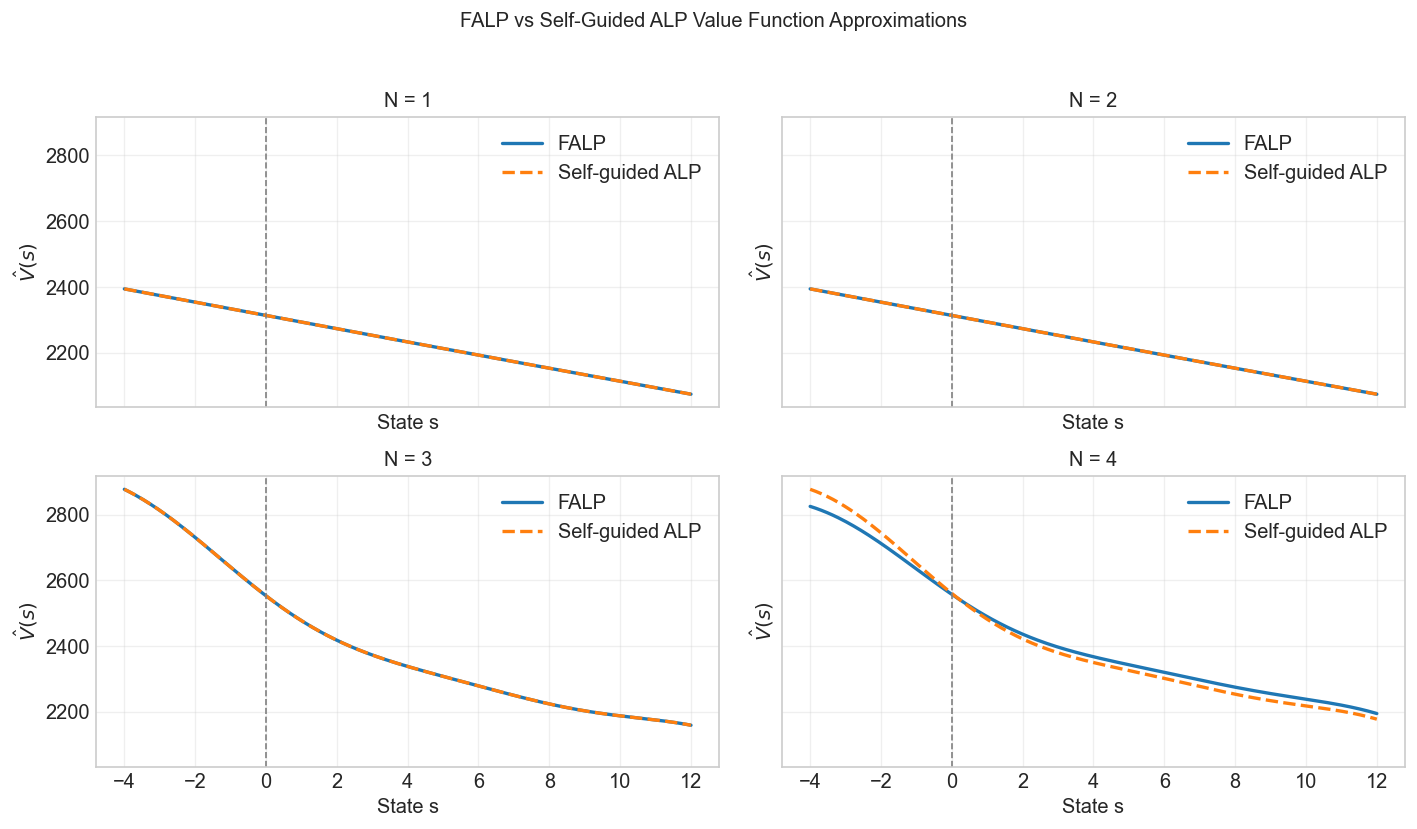

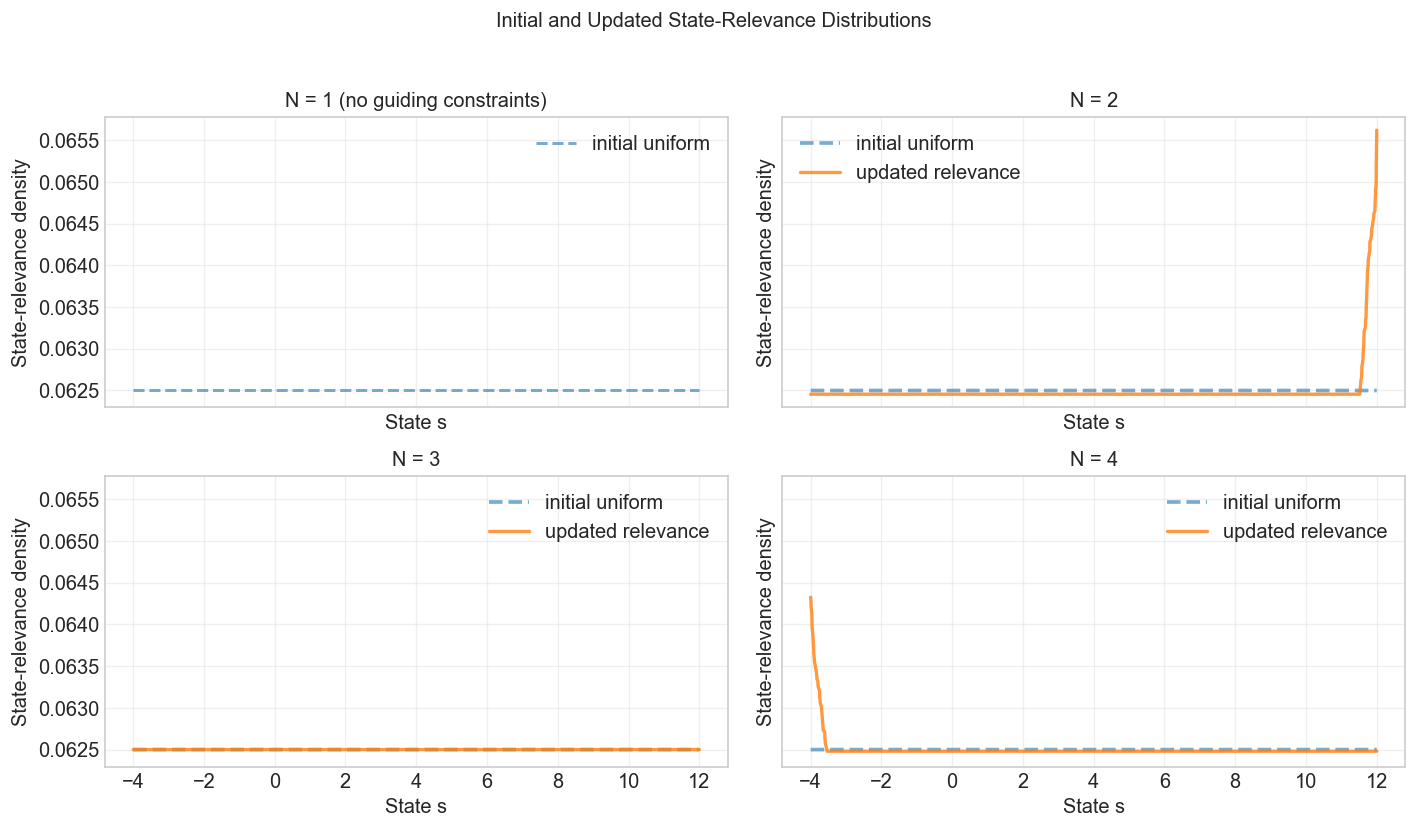

In [10]:
FALP_SGALP_COMPARISON_MAX_RANDOM_FEATURES = 4
FALP_SGALP_COMPARISON_NUM_CONSTRAINTS = tutorial_config.falp.num_constraints
FALP_SGALP_COMPARISON_NUM_STATE_RELEVANCE_SAMPLES = tutorial_config.falp.num_state_relevance_samples
FALP_SGALP_COMPARISON_NUM_GUIDING_STATES = tutorial_config.sgalp.guiding.num_guiding_states
FALP_SGALP_COMPARISON_BANDWIDTH_CHOICES = (0.1, 0.001)
FALP_SGALP_COMPARISON_BASIS_SEED = 444
FALP_SGALP_COMPARISON_GUIDING_VIOLATION = 0.0
FALP_SGALP_COMPARISON_GUIDING_RELAX_FRACTION = 0.0
FALP_SGALP_COMPARISON_GUIDING_ABS_FLOOR = 1e-7
FALP_SGALP_COMPARISON_GUIDING_RETRY_SCALES = (1.0,)

comparison_results = run_falp_and_sgalp_comparison(
    sgalp_class=SelfGuidedALP,
    max_random_features=FALP_SGALP_COMPARISON_MAX_RANDOM_FEATURES,
    num_constraints=FALP_SGALP_COMPARISON_NUM_CONSTRAINTS,
    num_state_relevance_samples=FALP_SGALP_COMPARISON_NUM_STATE_RELEVANCE_SAMPLES,
    num_guiding_states=FALP_SGALP_COMPARISON_NUM_GUIDING_STATES,
    bandwidth_choices=FALP_SGALP_COMPARISON_BANDWIDTH_CHOICES,
    basis_seed=FALP_SGALP_COMPARISON_BASIS_SEED,
    guiding_violation=FALP_SGALP_COMPARISON_GUIDING_VIOLATION,
    guiding_relax_fraction=FALP_SGALP_COMPARISON_GUIDING_RELAX_FRACTION,
    guiding_abs_floor=FALP_SGALP_COMPARISON_GUIDING_ABS_FLOOR,
    guiding_retry_scales=FALP_SGALP_COMPARISON_GUIDING_RETRY_SCALES,
    inventory_config=tutorial_config.inventory,
)

plot_falp_vs_sgalp_vfas_and_relevance(comparison_results, figsize=(12, 7), fontsize=12)


---